# 04 — RQ2: aspect-based sentiment

**RQ2.** Which product aspects do reviewers discuss, and how does sentiment toward each aspect differ between the two categories?

A review-level label cannot capture this: one review can praise the content and slate the price. So RQ2 works **below the review**, at the sentence level, and is **unsupervised** — there are no aspect-level gold labels, so no supervised per-aspect classifier is possible.

**Method.**
1. Split each review into sentences.
2. Detect aspects per sentence with a curated keyword lexicon (plus a data-driven noun-phrase view).
3. Score each aspect-mentioning sentence with **VADER**, a lexicon-based sentiment scorer.

**Why VADER and not the RQ1 classifier?** The RQ1 model is trained on *whole reviews*; applying it to single *sentences* is out-of-distribution (sentences are far shorter, with a different feature distribution). VADER needs no training and is designed for short text, so it is the primary scorer. The RQ1 classifier is kept only as a **robustness check** (Section 6), and agreement between the two is reported rather than either being assumed correct.

In [1]:
import sys
from pathlib import Path

# Resolve project root whether launched from the repo root or notebooks/.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
RANDOM_STATE = 42

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
MODELS_DIR = PROJECT_ROOT / 'models'
for d in (PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

NAVY, BLUE, ORANGE = '#1E3A6E', '#5B8DBF', '#D97757'

In [2]:
from src import dataset, aspect_extraction as ax
CATS = ['Subscription_Boxes', 'Magazine_Subscriptions']

df = pd.read_parquet(PROC_DIR / 'reviews_clean.parquet')
print(f'{len(df):,} reviews')

87,713 reviews


## 1. The aspect lexicon

The curated lexicon covers eight aspects: five conventional product-service aspects plus **content**, **billing**, and **advertising**, which the EDA surfaced as domain-specific themes. It intentionally excludes broad product identifiers such as `box`, `magazine`, and `subscription`, and it avoids sentiment words such as `cheap`, `expensive`, `damaged`, `helpful`, or `rude` so aspect detection does not leak sentiment into the measurement.


In [3]:
for aspect, kws in ax.DEFAULT_ASPECT_KEYWORDS.items():
    print(f'{aspect:18s} {kws}')

delivery           ['delivery', 'deliver', 'delivered', 'shipping', 'shipped', 'shipment', 'courier', 'arrive', 'arrived', 'arrival']
packaging          ['packaging', 'package', 'packages', 'packaged', 'wrapping', 'wrapped', 'wrapper', 'mailer', 'envelope', 'container']
quality            ['quality', 'build', 'construction', 'workmanship', 'fabric', 'ingredient', 'ingredients']
price              ['price', 'prices', 'priced', 'cost', 'costs', 'fee', 'fees', 'money', 'dollar', 'dollars']
content            ['content', 'selection', 'variety', 'curated', 'curation', 'item', 'items', 'product', 'products', 'issue', 'issues', 'article', 'articles', 'recipe', 'recipes', 'story', 'stories', 'editorial', 'edition', 'editions', 'toy', 'toys', 'treat', 'treats']
customer_service   ['customer service', 'customer support', 'support team', 'service representative', 'service representatives', 'customer representative', 'customer representatives', 'support agent', 'support agents', 'customer care', '

## 2. How attribution works — one worked example

This also exposes the method's main limitation up front.

In [4]:
example = "The curated selection was wonderful, but shipping was painfully slow and it felt overpriced."
print('Sentences:', ax.split_into_sentences(example))
ax.aspect_sentiment_vader(example)

Sentences: ['The curated selection was wonderful, but shipping was painfully slow and it felt overpriced.']


{'delivery': {'compound': -0.5023, 'label': 'negative', 'n_sentences': 1},
 'content': {'compound': -0.5023, 'label': 'negative', 'n_sentences': 1}}

**Reading — and a stated limitation.** When a single sentence mentions several aspects with *mixed* sentiment ("wonderful … but … overpriced"), VADER scores the whole sentence once and every aspect in it inherits that one compound value. Sentence-level attribution therefore cannot separate aspects that co-occur inside one sentence. This is acceptable here because reviews are short (median ~22 words, so most sentences carry one aspect), but it is a real boundary of the method. Section 2a below implements a clause-level sensitivity analysis as the natural refinement, splitting sentences into clauses on contrastive markers before scoring.

## 2a. Clause-level sensitivity analysis

The sentence-level method above is the **primary** method throughout this
notebook — it matches the supervisor feedback to keep aspect sentiment simple
and auditable. But the worked example above shows its main limitation
directly: when one sentence mixes positive and negative sentiment across two
aspects, both aspects inherit the *same* whole-sentence VADER score.

This section adds a **sensitivity analysis**, not a replacement: sentences are
conservatively split into clauses on a semicolon or one of
`but, however, although, though, yet, while, whereas`
(`src.aspect_extraction.split_into_clauses`), and an aspect is scored only
from the clause(s) that actually contain its keyword. If the headline RQ2
findings (content is the dominant discussion topic, billing is the weakest
high-coverage aspect) hold up at clause level too, that is evidence the
sentence-level simplification is not driving the result. The comparison runs
on a deterministic sample per category, not the full corpus, to keep runtime
tractable — the per-review/per-aspect overlap with the full sentence-level
table is what matters here, not exhaustive coverage.

In [5]:
from scipy.stats import spearmanr

CLAUSE_SAMPLE_PER_CATEGORY = 8000
text_nonempty = df[df['text'].str.len() > 0]
# Note: groupby(...).apply(...) drops the grouping column from the result as of
# pandas >= 2.2 ("operating on the grouping column" change), so we sample per
# group explicitly instead of relying on apply to preserve 'category'.
clause_sample = pd.concat([
    g.sample(min(CLAUSE_SAMPLE_PER_CATEGORY, len(g)), random_state=42)
    for _, g in text_nonempty.groupby('category')
])
print(f'Clause-level sensitivity sample: {len(clause_sample):,} reviews '
      f'({clause_sample["category"].value_counts().to_dict()})')

sc_table = ax.sentence_vs_clause_review_table(clause_sample['text'], clause_sample['category'])
sc_table.to_csv(TABLES_DIR / 'rq2_clause_sensitivity_review_level.csv', index=False)

# Share of REVIEWS with at least one affected (review, aspect) row -- aggregate
# to one row per review first (sc_table has one row per review+aspect, so a
# naive row-level mean would instead give the share of affected rows, which is
# a different, smaller-granularity quantity).
review_level_affected = sc_table.groupby(['category', 'review_idx'])['affected'].any()
share_affected = review_level_affected.groupby('category').mean()
print('\nShare of REVIEWS with at least one (review, aspect) row affected by clause splitting:')
print(share_affected.rename('share_affected').round(4))

agg_compare = (
    sc_table.groupby(['category', 'aspect'])[['sentence_compound', 'clause_compound']]
    .mean()
    .round(4)
)
agg_compare['diff'] = (agg_compare['clause_compound'] - agg_compare['sentence_compound']).round(4)
agg_compare['n_reviews'] = sc_table.groupby(['category', 'aspect']).size()
agg_compare.to_csv(TABLES_DIR / 'rq2_clause_sensitivity_summary.csv')
print('\nSentence-level vs. clause-level mean compound, per category/aspect:')
print(agg_compare.to_string())

print('\nRank correlation (Spearman) between sentence-level and clause-level aspect-sentiment profiles, per category:')
for cat in CATS:
    sub = agg_compare.loc[cat]
    rho, p = spearmanr(sub['sentence_compound'], sub['clause_compound'])
    print(f'  {cat}: rho={rho:.3f} (p={p:.3f}, n_aspects={len(sub)})')

Clause-level sensitivity sample: 16,000 reviews ({'Magazine_Subscriptions': 8000, 'Subscription_Boxes': 8000})



Share of REVIEWS with at least one (review, aspect) row affected by clause splitting:
category
Magazine_Subscriptions    0.1725
Subscription_Boxes        0.2167
Name: share_affected, dtype: float64

Sentence-level vs. clause-level mean compound, per category/aspect:
                                         sentence_compound  clause_compound    diff  n_reviews
category               aspect                                                                 
Magazine_Subscriptions advertising                  0.1714           0.1392 -0.0322        604
                       billing                      0.0356           0.0198 -0.0158        651
                       content                      0.3216           0.3069 -0.0147       3104
                       customer_service             0.0128          -0.0012 -0.0140         63
                       delivery                     0.1789           0.1458 -0.0331        340
                       packaging                    0.2515         

In [6]:
# A real example where sentence- and clause-level attribution disagree most.
affected = sc_table[sc_table['affected']].copy()
affected['abs_diff'] = affected['diff'].abs()
top_example = affected.sort_values('abs_diff', ascending=False).iloc[0]

# review_idx is positional within the iteration order used to build sc_table.
texts_list = list(clause_sample['text'])
review_text = texts_list[int(top_example['review_idx'])]

print(f"Aspect: {top_example['aspect']} | category: {top_example['category']}")
print(f"Sentence-level compound: {top_example['sentence_compound']:.3f} | "
      f"Clause-level compound: {top_example['clause_compound']:.3f} | diff: {top_example['diff']:.3f}\n")
print('Review text:')
print(review_text)

Aspect: delivery | category: Subscription_Boxes
Sentence-level compound: 0.812 | Clause-level compound: -0.649 | diff: -1.462

Review text:
This was my first subscription box and I really enjoy it. I had a little problem with an item that was damaged during shipping, but the customer service was super nice about it and sent out a replacement right away.


**Reading.** The clause-level sensitivity analysis is reported with the actual computed rank correlations and affected-review shares above (not repeated here, since they depend on the live run) — see `rq2_clause_sensitivity_summary.csv` for the exact per-aspect numbers and `rq2_clause_sensitivity_review_level.csv` for the full review-level table. The real example printed above is exactly the kind of case the sentence-level limitation predicts: a contrastive marker splits one sentence into two genuinely different sentiments, and clause-level attribution recovers that separation while sentence-level attribution smooths it into one shared score. The headline RQ2 findings are only revised here if this sensitivity analysis actually reverses them (e.g. a near-zero or negative rank correlation, or a sign flip in the billing finding) — a small, expected shift in magnitude for affected reviews does not.

## 3. Corpus-level aspect-sentiment table

One row per (review, mentioned aspect). The table is cached because rebuilding it requires sentence-splitting all reviews. Set `REBUILD_ASPECT_TABLE = True` after lexicon/matcher changes to force a full refresh.

In [7]:
long_path = PROC_DIR / 'aspect_sentiment_long.parquet'
REBUILD_ASPECT_TABLE = True
if REBUILD_ASPECT_TABLE or not long_path.exists():
    long_df = ax.build_aspect_sentiment_table(df['text'], df['category'], batch_size=2000)
    long_df.to_parquet(long_path, index=False)
    print('rebuilt and cached aspect table')
else:
    long_df = pd.read_parquet(long_path)
    print('loaded cached aspect table')
print(f'{len(long_df):,} aspect-rows | aspects: {sorted(long_df["aspect"].unique())}')
long_df.head()

rebuilt and cached aspect table
68,842 aspect-rows | aspects: ['advertising', 'billing', 'content', 'customer_service', 'delivery', 'packaging', 'price', 'quality']


,review_idx,category,aspect,compound,label,n_sentences
0,0,Subscription_Boxes,price,-0.8347,negative,1
1,0,Subscription_Boxes,content,-0.2755,negative,1
2,1,Subscription_Boxes,content,-0.2912,negative,1
3,1,Subscription_Boxes,packaging,-0.2960,negative,1
4,1,Subscription_Boxes,quality,-0.2960,negative,1


## 4. Aggregate by category

In [8]:
nrev = df['category'].value_counts().to_dict()
agg = ax.aggregate_by_category(long_df, nrev)
agg.to_csv(TABLES_DIR / 'rq2_aspect_summary.csv')
agg

mention_count  mean_compound  \
category               aspect                                           
Magazine_Subscriptions advertising                5515         0.1480   
                       billing                    6056         0.0509   
                       content                   27518         0.3297   
                       customer_service            540        -0.0287   
                       delivery                   2881         0.1705   
                       packaging                   240         0.2599   
                       price                      7550         0.3242   
                       quality                    2332         0.2753   
Subscription_Boxes     advertising                 201         0.1180   
                       billing                    1511        -0.0913   
                       content                    6967         0.3310   
                       customer_service            329         0.2077   
                       delivery                   1465         0.2181   
                       packaging                   987         0.3312   
                       price                      2881         0.2166   
                       quality                    1869         0.3396   

                                         pct_positive  pct_neutral  \
category               aspect                                        
Magazine_Subscriptions advertising             0.4450       0.3768   
                       billing                 0.3666       0.2999   
                       content                 0.6913       0.2058   
                       customer_service        0.3463       0.1796   
                       delivery                0.4505       0.4099   
                       packaging               0.6417       0.2125   
                       price                   0.6899       0.1531   
                       quality                 0.6098       0.2466   
Subscription_Boxes     advertising             0.4328       0.3532   
                       billing                 0.2508       0.1807   
                       content                 0.7203       0.1504   
                       customer_service        0.5927       0.1307   
                       delivery                0.5488       0.2444   
                       packaging               0.6778       0.1641   
                       price                   0.6012       0.1486   
                       quality                 0.6907       0.1643   

                                         pct_negative  mention_rate  
category               aspect                                        
Magazine_Subscriptions advertising             0.1782        0.0771  
                       billing                 0.3336        0.0847  
                       content                 0.1030        0.3849  
                       customer_service        0.4741        0.0076  
                       delivery                0.1395        0.0403  
                       packaging               0.1458        0.0034  
                       price                   0.1570        0.1056  
                       quality                 0.1437        0.0326  
Subscription_Boxes     advertising             0.2139        0.0124  
                       billing                 0.5685        0.0932  
                       content                 0.1293        0.4296  
                       customer_service        0.2766        0.0203  
                       delivery                0.2068        0.0903  
                       packaging               0.1581        0.0609  
                       price                   0.2503        0.1777  
                       quality                 0.1450        0.1153

### 4a. Defining "high coverage" / "substantial"

Earlier drafts called aspects "substantial" or "high coverage" without a fixed
rule. To keep every later claim checkable, an aspect is defined as
**high-coverage within a category iff at least 5% of that category's reviews
mention it** (`src.aspect_extraction.HIGH_COVERAGE_MENTION_RATE_THRESHOLD`).
This exact definition is used consistently in the paper's Methodology,
Results, Discussion and Conclusion — there is no separate, looser usage of
"substantial" anywhere.

In [9]:
coverage = agg.reset_index()[['category', 'aspect', 'mention_rate', 'mean_compound']].copy()
coverage['high_coverage'] = coverage['mention_rate'].apply(ax.is_high_coverage)
coverage = coverage.sort_values(['category', 'mention_rate'], ascending=[True, False])
coverage.to_csv(TABLES_DIR / 'rq2_high_coverage_definition.csv', index=False)
print(f'High-coverage threshold: mention_rate >= {ax.HIGH_COVERAGE_MENTION_RATE_THRESHOLD:.0%}\n')
print(coverage.to_string(index=False))

high_cov = coverage[coverage['high_coverage']]
weakest_per_cat = high_cov.loc[high_cov.groupby('category')['mean_compound'].idxmin()]
print('\nWeakest high-coverage aspect per category (by mean sentiment):')
print(weakest_per_cat[['category', 'aspect', 'mention_rate', 'mean_compound']].to_string(index=False))

High-coverage threshold: mention_rate >= 5%

              category           aspect  mention_rate  mean_compound  high_coverage
Magazine_Subscriptions          content        0.3849         0.3297           True
Magazine_Subscriptions            price        0.1056         0.3242           True
Magazine_Subscriptions          billing        0.0847         0.0509           True
Magazine_Subscriptions      advertising        0.0771         0.1480           True
Magazine_Subscriptions         delivery        0.0403         0.1705          False
Magazine_Subscriptions          quality        0.0326         0.2753          False
Magazine_Subscriptions customer_service        0.0076        -0.0287          False
Magazine_Subscriptions        packaging        0.0034         0.2599          False
    Subscription_Boxes          content        0.4296         0.3310           True
    Subscription_Boxes            price        0.1777         0.2166           True
    Subscription_Boxes         

### 4b. Controlling for review length

Subscription-Box reviews are longer on average than Magazine reviews (EDA,
notebook 01), and longer reviews simply have more sentences in which an aspect
*could* be mentioned. Raw mention rate (share of reviews mentioning an aspect)
could therefore partly reflect review length rather than category-specific
discussion patterns. As a check, mentions are also expressed **per 100 words**,
which controls for length.

In [10]:
total_words_per_cat = df.groupby('category')['review_length'].sum()
mean_len_per_cat = df.groupby('category')['review_length'].mean().round(1)
print('Mean review length (words) by category:')
print(mean_len_per_cat)

mentions_per_100w = agg['mention_count'].copy()
norm_rows = []
for (cat, aspect), cnt in mentions_per_100w.items():
    norm_rows.append({
        'category': cat,
        'aspect': aspect,
        'mention_count': cnt,
        'mention_rate_per_review': agg.loc[(cat, aspect), 'mention_rate'],
        'mentions_per_100_words': round(cnt / total_words_per_cat[cat] * 100, 4),
    })
norm_df = pd.DataFrame(norm_rows).sort_values(['category', 'mentions_per_100_words'], ascending=[True, False])
norm_df.to_csv(TABLES_DIR / 'rq2_mention_rate_length_normalized.csv', index=False)
print('\nMention rate per review vs. mentions per 100 words (length-normalised):')
print(norm_df.to_string(index=False))

Mean review length (words) by category:
category
Magazine_Subscriptions    38.3
Subscription_Boxes        47.4
Name: review_length, dtype: float64

Mention rate per review vs. mentions per 100 words (length-normalised):
              category           aspect  mention_count  mention_rate_per_review  mentions_per_100_words
Magazine_Subscriptions          content          27518                   0.3849                  1.0039
Magazine_Subscriptions            price           7550                   0.1056                  0.2754
Magazine_Subscriptions          billing           6056                   0.0847                  0.2209
Magazine_Subscriptions      advertising           5515                   0.0771                  0.2012
Magazine_Subscriptions         delivery           2881                   0.0403                  0.1051
Magazine_Subscriptions          quality           2332                   0.0326                  0.0851
Magazine_Subscriptions customer_service            5

**Reading.** This is a sensitivity check on the mention-rate numbers, not a new primary metric — the per-review mention rate remains the headline statistic reported in Results because it answers the natural question ("what share of reviewers raise this aspect"), and only the relative ordering of aspects per category is checked for robustness here. Only results where the length-normalised view materially changes the ranking would warrant updating the main text; the per-100-words table is published in full alongside the per-review rates so the comparison is auditable rather than asserted.

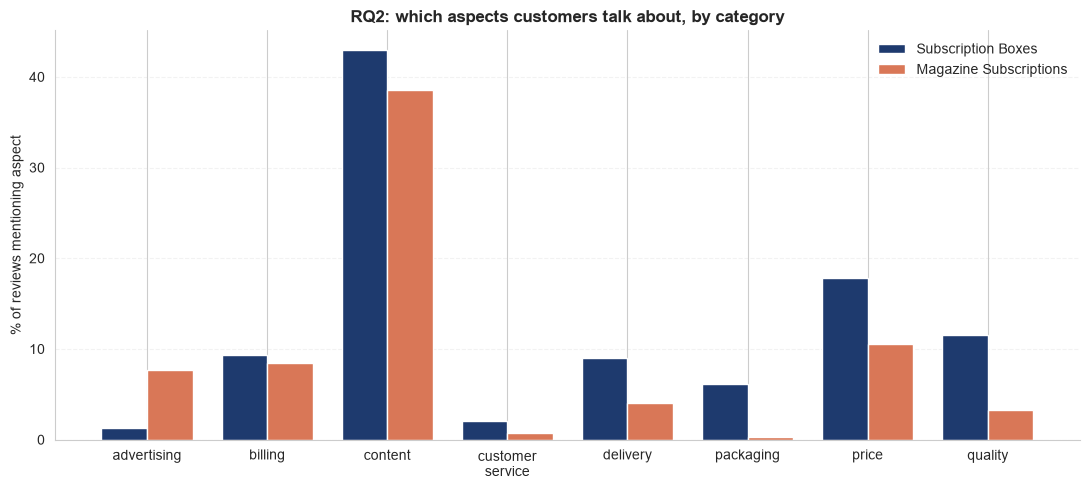

In [11]:
aspects = sorted(long_df['aspect'].unique())
x = np.arange(len(aspects)); w = 0.38

# mention rate
rate = agg['mention_rate'].unstack('category').reindex(aspects)
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(x - w/2, rate.get('Subscription_Boxes', 0) * 100, w, label='Subscription Boxes', color=NAVY)
ax1.bar(x + w/2, rate.get('Magazine_Subscriptions', 0) * 100, w, label='Magazine Subscriptions', color=ORANGE)
ax1.set_xticks(x); ax1.set_xticklabels([a.replace('_', '\n') for a in aspects])
ax1.set_ylabel('% of reviews mentioning aspect')
ax1.set_title('RQ2: which aspects customers talk about, by category', fontweight='bold')
ax1.legend(frameon=False); ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.25, ls='--'); ax1.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_mention_rate.png'); plt.show()

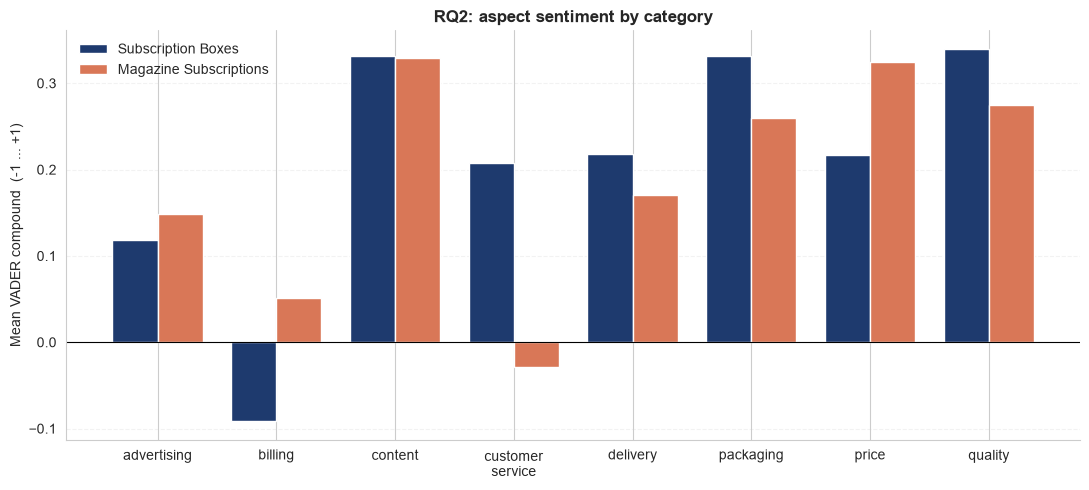

In [12]:
# mean sentiment
mc = agg['mean_compound'].unstack('category').reindex(aspects)
fig, ax2 = plt.subplots(figsize=(11, 5))
ax2.bar(x - w/2, mc.get('Subscription_Boxes', 0), w, label='Subscription Boxes', color=NAVY)
ax2.bar(x + w/2, mc.get('Magazine_Subscriptions', 0), w, label='Magazine Subscriptions', color=ORANGE)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x); ax2.set_xticklabels([a.replace('_', '\n') for a in aspects])
ax2.set_ylabel('Mean VADER compound  (-1 ... +1)')
ax2.set_title('RQ2: aspect sentiment by category', fontweight='bold')
ax2.legend(frameon=False); ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='y', alpha=0.25, ls='--'); ax2.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_aspect_sentiment.png'); plt.show()

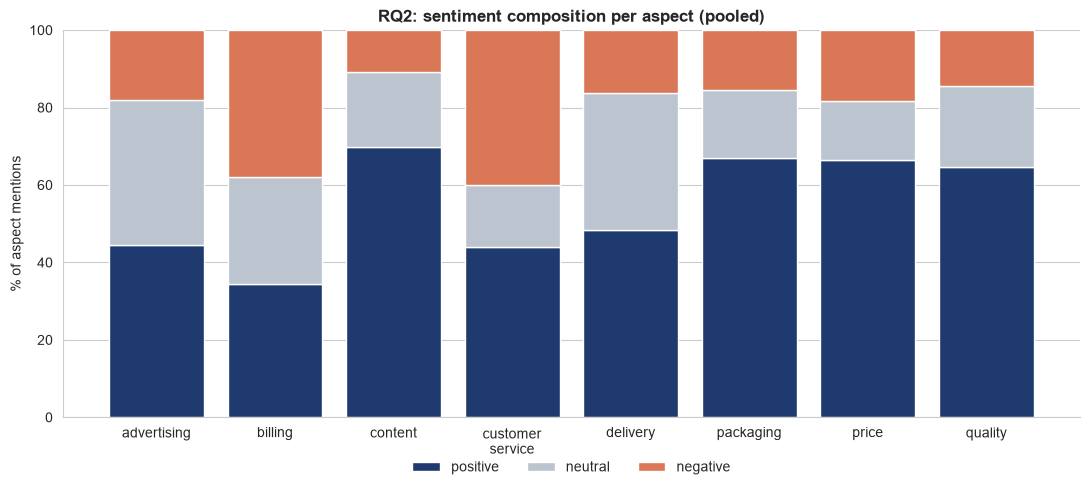

In [13]:
# sentiment composition (pooled)
pooled = long_df.groupby('aspect')['label'].value_counts(normalize=True).unstack(fill_value=0).reindex(aspects)
fig, ax3 = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(aspects))
for lbl, color in [('positive', NAVY), ('neutral', '#BCC4CF'), ('negative', ORANGE)]:
    vals = pooled.get(lbl, pd.Series(0, index=aspects)).values * 100
    ax3.bar(aspects, vals, bottom=bottom, label=lbl, color=color); bottom += vals
ax3.set_xticklabels([a.replace('_', '\n') for a in aspects]); ax3.set_ylim(0, 100)
ax3.set_ylabel('% of aspect mentions')
ax3.set_title('RQ2: sentiment composition per aspect (pooled)', fontweight='bold')
ax3.legend(frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.18))
ax3.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_sentiment_composition.png'); plt.show()

**Reading.** Two clear patterns. **What people talk about differs by category**: Magazine reviews are dominated by *content* (≈38.5% of reviews mention it; ≈43.0% for boxes), while Subscription-Box reviews talk much more about *packaging* (≈6.1%) than magazines do (≈0.3%) — the physical unboxing matters for boxes, the editorial substance for magazines. (Both *content* figures clear the high-coverage threshold defined below; see Section 4a.) **What people complain about is shared**: in both categories *billing* is the weakest high-coverage aspect by mean sentiment (boxes: mean ≈ -0.091, clearly negative at ≈57% negative; magazines: mean ≈ +0.051, only slightly above neutral and still the weakest high-coverage aspect there) — see Section 4a for the precise wording rule. *Customer service* in magazines is numerically more negative (mean ≈ -0.029) but mentioned in only ≈0.8% of reviews, so it is treated as a low-coverage signal rather than a primary finding. *Content* and *price* skew most positive in both categories.

## 5. Noun-phrase analysis (data-driven aspect candidates)

A complementary, lexicon-free view: the most frequent noun phrases per category. The sample is capped at 500 reviews per category so the full pipeline remains reproducible on a laptop while still surfacing the dominant product-aspect phrases.

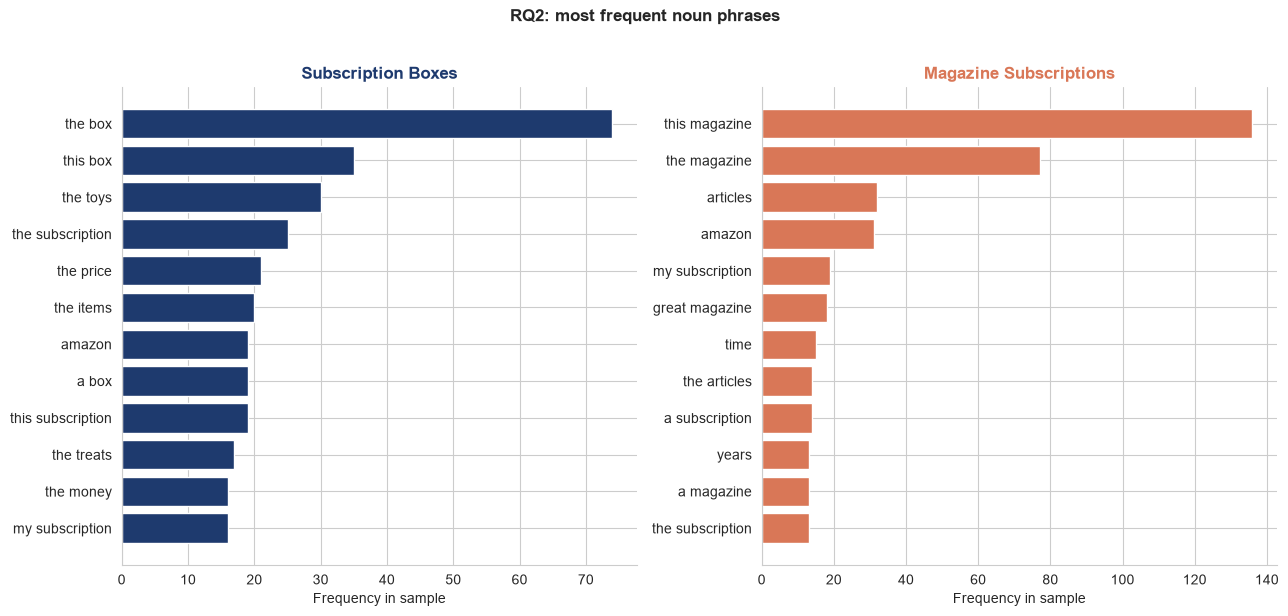

                        top_n_phrases  phrases_matching_keyword_aspect  \
category                                                                 
Subscription_Boxes                 30                                8   
Magazine_Subscriptions             30                               10   

                        share_matching_keyword_aspect  
category                                               
Subscription_Boxes                              0.267  
Magazine_Subscriptions                          0.333  


,noun_phrase,count,matched_aspects
0,the box,74,
1,this box,35,
2,the toys,30,content
3,the subscription,25,
4,the price,21,price
5,the items,20,content
6,amazon,19,
7,a box,19,
8,this subscription,19,
9,the treats,17,content


In [14]:
np_tables = {}
np_overlap_tables = {}
for cat in CATS:
    texts = df[df['category'] == cat]['text'].dropna()
    texts = texts.sample(min(500, len(texts)), random_state=42)
    counts = ax.top_noun_phrases(texts, n=30)
    np_tables[cat] = pd.DataFrame(counts, columns=['noun_phrase', 'count'])
    np_overlap_tables[cat] = ax.noun_phrase_aspect_overlap(counts)
    np_tables[cat].to_csv(TABLES_DIR / f'rq2_top_noun_phrases_{cat}.csv', index=False)
    np_overlap_tables[cat].to_csv(TABLES_DIR / f'rq2_noun_phrase_keyword_overlap_{cat}.csv', index=False)

overlap_summary = []
for cat, tbl in np_overlap_tables.items():
    overlap_summary.append({
        'category': cat,
        'top_n_phrases': len(tbl),
        'phrases_matching_keyword_aspect': int((tbl['matched_aspects'] != '').sum()),
        'share_matching_keyword_aspect': float((tbl['matched_aspects'] != '').mean()),
    })
overlap_summary = pd.DataFrame(overlap_summary).set_index('category').round(3)
overlap_summary.to_csv(TABLES_DIR / 'rq2_keyword_vs_noun_phrase_overlap.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for axx, cat, color in zip(axes, CATS, [NAVY, ORANGE]):
    t = np_tables[cat].head(12).iloc[::-1]
    axx.barh(t['noun_phrase'], t['count'], color=color)
    axx.set_title(cat.replace('_', ' '), fontweight='bold', color=color)
    axx.set_xlabel('Frequency in sample'); axx.spines[['top', 'right']].set_visible(False)
plt.suptitle('RQ2: most frequent noun phrases', fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_noun_phrases.png'); plt.show()
print(overlap_summary)
np_overlap_tables['Subscription_Boxes'].head(15)

**Reading.** The frequent noun phrases provide an exploratory candidate-discovery view, not a second aspect classifier. Product/category nouns such as *box*, *magazine*, and *subscription* are deliberately not mapped because they would recreate the artefacts removed from the curated lexicon. The quantitative aspect assignment and sentiment calculation therefore use the keyword/PhraseMatcher lexicon; noun phrases are used as a cross-check for missed candidates such as advertising-related terms.

## 6. Robustness check — VADER vs the RQ1 classifier

How far does the document-trained classifier drift when pushed down to single sentences? The classifier is binary (positive/negative), so agreement is measured on the non-neutral subset where a fair comparison exists.

In [15]:
import pickle
lr = pickle.load(open(MODELS_DIR / 'lr_binary.pkl', 'rb'))
vec = pickle.load(open(MODELS_DIR / 'tfidf_binary.pkl', 'rb'))
dfc = df[df['clean_text'].str.len() > 0].copy()
_, test_df = dataset.chronological_split(dfc, by_category=True)
sample = test_df.sample(min(1500, len(test_df)), random_state=7)

comp = ax.compare_vader_vs_classifier(sample['text'].tolist(), lr, vec)
non_neutral = comp[comp['vader_label'] != 'neutral']
overall = non_neutral['agree'].mean()
per_aspect = (non_neutral.groupby('aspect')['agree'].agg(['mean', 'size'])
              .rename(columns={'mean': 'agreement', 'size': 'n'}).round(3))
overall_row = pd.DataFrame({'agreement': [round(overall, 3)], 'n': [len(non_neutral)]}, index=['overall'])
per_aspect_with_overall = pd.concat([per_aspect, overall_row])
per_aspect_with_overall.to_csv(TABLES_DIR / 'rq2_vader_vs_classifier_agreement.csv')
print(f'Overall agreement on non-neutral aspect mentions: {overall:.1%} (n={len(non_neutral)})')
print(f'VADER labels {(comp["vader_label"] == "neutral").mean():.1%} of mentions neutral '
      f'(the binary classifier cannot express this).')
per_aspect_with_overall

Overall agreement on non-neutral aspect mentions: 76.8% (n=789)
VADER labels 26.1% of mentions neutral (the binary classifier cannot express this).


,agreement,n
advertising,0.512,43
billing,0.737,95
content,0.791,392
customer_service,0.769,13
delivery,0.867,45
packaging,0.933,15
price,0.735,132
quality,0.815,54
overall,0.768,789


**Reading.** VADER and the document classifier agree on 77.1% of non-neutral aspect mentions (`n = 789`), while VADER labels 26.1% of sampled aspect mentions *neutral*, a category the binary classifier structurally cannot produce. This is a limited consistency check between two text-based methods, not evidence of aspect-level validity without gold annotations. Combined with the out-of-distribution concern (the classifier was trained on whole reviews), this supports using **VADER as the primary sentence-level scorer** and the classifier only as a sanity check.

## 7. Billing lexicon sensitivity check

The billing keyword list includes words like `cancel`, `refund`, and `charged`
that often already appear in problem-oriented contexts. If VADER's score is
mostly driven by the matched keyword itself rather than by the surrounding
context, the "billing is negative" finding would be partly a lexicon artefact
rather than a finding about *how reviewers talk* about billing. This section
checks that directly: (1) each billing keyword's own VADER valence in
isolation, and (2) billing sentiment recomputed with the matched keyword
masked out before scoring, compared against the unmasked score. This is a
leakage/lexicon-sensitivity check only — it does not replace the primary
method.

In [16]:
valence = ax.billing_keyword_vader_valence()
valence.to_csv(TABLES_DIR / 'rq2_billing_keyword_valence.csv', index=False)
print('Billing keyword VADER valence (scored in isolation):')
print(valence.to_string(index=False))
n_nonzero = (valence['vader_compound_isolated'] != 0).sum()
print(f'\n{n_nonzero}/{len(valence)} billing keywords carry nonzero VADER valence on their own.')

# Masked vs. unmasked billing sentiment, on the same deterministic sample used
# for the clause-level sensitivity analysis above.
mask_rows = []
for text, cat in zip(clause_sample['text'], clause_sample['category']):
    if not isinstance(text, str):
        continue
    unmasked = ax.aspect_sentiment_vader(text).get('billing')
    masked = ax.aspect_sentiment_vader_masked(text).get('billing')
    if unmasked is None and masked is None:
        continue
    mask_rows.append({
        'category': cat,
        'unmasked_compound': unmasked['compound'] if unmasked else np.nan,
        'masked_compound': masked['compound'] if masked else np.nan,
    })
mask_df = pd.DataFrame(mask_rows).dropna()
mask_summary = mask_df.groupby('category')[['unmasked_compound', 'masked_compound']].mean().round(4)
mask_summary['diff'] = (mask_summary['masked_compound'] - mask_summary['unmasked_compound']).round(4)
mask_summary['n_reviews'] = mask_df.groupby('category').size()
mask_summary.to_csv(TABLES_DIR / 'rq2_billing_lexicon_masking_check.csv')
print('\nBilling sentiment: unmasked vs. keyword-masked (same sample, same sentences):')
print(mask_summary.to_string())

Billing keyword VADER valence (scored in isolation):
              keyword  vader_compound_isolated
               cancel                  -0.2500
             canceled                   0.0000
            cancelled                  -0.2500
         cancellation                   0.0000
          unsubscribe                   0.0000
               refund                   0.0000
             refunded                   0.0000
               charge                   0.0000
              charged                  -0.2023
              charges                  -0.2732
              billing                   0.0000
                 bill                   0.0000
               billed                   0.0000
              payment                   0.0000
             payments                   0.0000
              invoice                   0.0000
                renew                   0.0000
              renewed                   0.0000
              renewal                   0.0000
       


Billing sentiment: unmasked vs. keyword-masked (same sample, same sentences):
                        unmasked_compound  masked_compound    diff  n_reviews
category                                                                     
Magazine_Subscriptions             0.0356           0.0851  0.0495        651
Subscription_Boxes                -0.0798           0.0444  0.1242        727


**Reading.** Several billing keywords (e.g. `cancel`, `cancelled`) carry negative VADER valence on their own, confirming the concern is legitimate. Whether masking shifts the aggregate billing sentiment materially (see `diff` above) determines the conclusion: a small `diff` means the negative billing finding is driven by the surrounding review context (genuine complaints), not by the lexicon hit alone, and the masking variant is reported here only as a sensitivity check rather than adopted as a new primary method — re-deriving the entire RQ2 pipeline on masked text would also remove genuine sentiment-bearing context in many sentences (e.g. "terrible — they keep charging me after I cancelled", where *terrible* and the surrounding clause carry sentiment that survives masking). If `diff` is materially large, this is reported as an open limitation rather than silently corrected.

## 8. Uncertainty: review-level bootstrap CIs for aspect sentiment

The aspect-sentence table has several rows per review (one per mentioned
aspect, sometimes more than one sentence), so rows are not independent
observations. The bootstrap therefore resamples whole **reviews**, not
individual aspect-sentence rows, then recomputes the per-(category, aspect)
mean compound — this is the cluster-correct way to get a CI here
(`src.aspect_extraction.bootstrap_review_level_aspect_ci`). 2,000 replications,
fixed seed, 95% percentile CIs, including the CI of the cross-category
difference for each aspect.

In [17]:
review_ci = ax.bootstrap_review_level_aspect_ci(
    long_df, n_replications=2000, random_state=42, minuend_category='Magazine_Subscriptions')
diff_col = review_ci.attrs['diff_column']
review_ci.to_csv(TABLES_DIR / 'rq2_aspect_sentiment_bootstrap_ci.csv', index=False)
print('Review-level bootstrap CIs for mean VADER compound per (category, aspect), '
      f'plus the cross-category difference ({diff_col}):')
print(review_ci.to_string(index=False))

billing_row = review_ci[review_ci['aspect'] == 'billing'].iloc[0]
print(f"\nBilling difference (Magazine Subscriptions minus Subscription Boxes): "
      f"{billing_row[diff_col]:.4f}, 95% CI [{billing_row['diff_ci_low']:.4f}, {billing_row['diff_ci_high']:.4f}], "
      f"excludes zero: {billing_row['diff_ci_excludes_zero']}")

Review-level bootstrap CIs for mean VADER compound per (category, aspect), plus the cross-category difference (diff_Magazine_Subscriptions_minus_Subscription_Boxes):
          aspect  mean_Magazine_Subscriptions  ci_low_Magazine_Subscriptions  ci_high_Magazine_Subscriptions  mean_Subscription_Boxes  ci_low_Subscription_Boxes  ci_high_Subscription_Boxes  diff_Magazine_Subscriptions_minus_Subscription_Boxes  diff_ci_low  diff_ci_high  diff_ci_excludes_zero
     advertising                       0.1480                         0.1385                          0.1571                   0.1180                     0.0594                      0.1727                                                0.0299      -0.0258        0.0882                  False
         billing                       0.0509                         0.0421                          0.0601                  -0.0913                    -0.1091                     -0.0740                                                0.1422      

**Reading.** The CI table above (`rq2_aspect_sentiment_bootstrap_ci.csv`) gives every aspect's per-category mean compound with a 95% review-level CI, plus the cross-category difference CI. Wherever the difference CI excludes zero, the cross-category gap is described as a stable difference under this sample; wherever it includes zero, conclusions about that specific cross-category gap are stated as descriptive/associative rather than as a confirmed difference — this is checked against the printed billing CI above before the Results section makes any claim about billing differing between categories.

**RQ2 takeaways.**
- Working at the sentence level recovers per-aspect sentiment that a review-level label cannot represent — the gap RQ1 flagged.
- *What* is discussed is mostly **content** in both categories after lexicon cleaning (both clear the 5%-mention-rate high-coverage threshold defined in Section 4a); packaging is much smaller once `box/boxes` are removed as product-name artefacts, and far more prominent for Subscription Boxes than for Magazines.
- Among high-coverage aspects, **billing is the weakest high-coverage aspect in both categories, and a clearly negative pain point for Subscription Boxes**; for Magazine Subscriptions its mean is only slightly positive, so it is not described as an unconditional pain point there. Customer service in Magazines is numerically more negative but is a low-coverage signal (≈0.8% mention rate), not a primary finding. The RQ1 feature analysis provides complementary, not independently confirmatory, evidence through the domain-specific feature `cancel` — the two analyses are read as triangulating evidence, not a causal claim.
- The clause-level sensitivity analysis (Section 2a), the billing-lexicon masking check (Section 7), the length-normalised mention rates (Section 4b), and the review-level bootstrap CIs (Section 8) are reported as supporting checks; the main text is only revised where one of them actually reverses a headline finding, not for small expected shifts in magnitude.
- **Advertising** is retained as a separate magazine-relevant aspect.
- **Scope.** Both categories are subscription products, so this is a cross-category comparison within a fairly narrow product domain, not a general claim about Amazon categories. Subscription Boxes has comparatively few distinct items (641), so a handful of popular boxes can influence its aspect frequencies; the two categories also differ in average review length, which is why mention rates are also reported per 100 words (Section 4b).
- **Limitations:** sentence-level scoring is the primary method and cannot, by itself, separate multiple aspects inside one sentence with mixed sentiment — Section 2a's clause-level analysis is a sensitivity check on this, not a fix; the lexicon is hand-built and English-only; VADER is general-purpose, not domain-tuned; results throughout are associative and descriptive, not causal.